# Multimodal Learning

## Importing modules

In [ ]:
import os
import tarfile
import itertools
import random
import json
from typing import Any, Callable, List, Optional, Tuple, Dict
random.seed(42)
from collections import defaultdict

import numpy as np
import pandas as pd
from tqdm.autonotebook import tqdm
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision
from torchvision import models
from torch import nn
from torch.utils.data import Dataset,random_split,DataLoader,TensorDataset
import torch.nn.functional as F
import timm

import torchvision.transforms as transforms
from transformers import DistilBertModel, DistilBertConfig, DistilBertTokenizer
import torch.nn.functional as F
import torch.optim as optim
from sklearn.model_selection import train_test_split

<ipython-input-1-19278ae13da7>:12: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## Configuration

In [ ]:
class CFG:
    debug = False
    data_path = "./coco_single_class"
    output_dir = "/content/drive/MyDrive/Mutimodel-Learning/output"
    os.makedirs(output_dir, exist_ok=True)
    max_samples = -1 # max number of dataset samples to load
    batch_size = 64
    num_workers = 4
    head_lr = 1e-3
    image_encoder_lr = 1e-4
    text_encoder_lr = 1e-5
    weight_decay = 1e-3
    patience = 1
    factor = 0.8
    epochs = 10  # you can train for more epochs if you have the time and want to see better performance
    random_seed = 42
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    num_classes = 80

    model_name = 'tiny_vit_21m_224.dist_in22k_ft_in1k'
    image_embedding = 576
    text_encoder_model = "distilbert-base-uncased"
    text_embedding = 768
    text_tokenizer = "distilbert-base-uncased"
    max_token_length = 200

    pretrained = True # for both image encoder and text encoder
    trainable = True # for both image encoder and text encoder
    temperature = 1.0 # this is a learnable parameter in CLIP, but we ignore that for this demo

    # image size
    size = 224

    # for projection head; used for both image and text encoders
    num_projection_layers = 1
    projection_dim = 256
    dropout = 0.1

## Dataset Extract

In [ ]:
# Path to dataset archive
tar_path = "/content/drive/MyDrive/Multimodal Learning with Limited Labels and Missing Modalities/coco_single_class.tar.gz"

# Extract only if not already extracted
if not os.path.exists(CFG.data_path):
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(path=".")
    print("Dataset extracted successfully.")
else:
    print("Dataset already extracted.")

# List extracted structure
print("Extracted directory contents:")
print(os.listdir(CFG.data_path))

Dataset extracted successfully.
Extracted directory contents:
['val2017', 'train2017', 'annotations']


## Dataset Class

In [ ]:
def keystoint(annot_dict):
    """
    Helper function that fixes JSON dict indexes, as they are loaded as strings
    instead of ints.
    """
    for top_key, top_val in annot_dict.items():
        if top_key in ['annotations', 'class_name_dict']:
            annot_dict[top_key] = {int(k): v for k, v in annot_dict[top_key].items()}
    return annot_dict

class COCOSingleClassDataset(Dataset):
    """
    Torch Dataset for custom COCO split. Contains only images with a single
    class label, and has 5 captions per image.

    Batches return image, label, caption, and optionally tokenised captions.
    """
    def __init__(
        self,
        data_dir: str,
        split: str = 'train',
        transforms: Optional[Callable] = None,
        tokenizer: Optional[Callable] = None,
        max_token_length: int = 200,
        max_samples: int = -1,
        max_captions_per_image: int = 5,
        percent=100
    ) -> None:
        """
        Constructs the Dataset object.

        Parameters
        ----------
            data_dir : str
                dataset root directory
            split : str
                coco split to use, must be train or val
            transforms : Optional[Callable]
                pytorch transforms to apply to the images, typically a transforms.Compose() object or None
            tokenizer : Optional[Callable]
                tokenizer to apply to the captions, expects a HuggingFace tokenizer or None if not tokenizing
            max_token_length: int
                max length of tokens, if using tokenizer
            max_samples: int
                max number of samples to load from dataset, useful for debugging, value of -1 loads all samples
            max_captions_per_image: int
                max number of captions to load per image, set to 1 if evaluating image classification performance
        """
        assert max_captions_per_image <= 5, 'Only 5 captions available per image'
        assert max_captions_per_image > 0, 'Minimum 1 caption per image'
        assert split in ['train', 'val'], 'Invalid split'

        self.data_dir = data_dir
        if split == 'train':
            self.split = 'train2017'
        elif split == 'val':
            self.split = 'val2017'
        else:
            raise NotImplementedError
        self.img_dir = os.path.join(self.data_dir, self.split)
        self.transforms = transforms
        self.tokenizer = tokenizer
        self.max_token_length = max_token_length
        self.max_samples = max_samples
        self.max_captions_per_image = max_captions_per_image
        self.percent = percent
        self.random_seed = 42

        random.seed(self.random_seed)
        self.load_annotations()
        self.img_ids = self._annot_dict['ids']
        self.annotations = self._annot_dict['annotations']
        self.class_name_dict = self._annot_dict['class_name_dict']
        self.class_id_map = {orig: new for new, orig in enumerate(sorted(self.class_name_dict.keys()))}
        self.id_to_class = {v: k for k, v in self.class_id_map.items()}
        self.generate_samples()

    def __len__(self) -> int:
        return len(self.df_samples)

    def __getitem__(self, idx: int) -> Dict:
        """
        This function will be called automatically when loading batches from
        the dataloader. Batches are returned as a Dictionary object, with the
        keys:
            image : torch.Tensor[torch.float32]
                tensor of dim [B, C, H, W]
            label : torch.Tensor[torch.uint8]
                classification labels of each item in batch
            caption : str
                original caption, for visualisation or debugging purposes
            input_ids : torch.Tensor[torch.int64]
                if using tokenizer, returns a tensor containing tokenised captions
            attention_mask : torch.Tensor[torch.int64]
                if using tokenizer, returns a tensor containing attention masks for tokens
        """
        sample = self.df_samples.iloc[idx]
        item = {}
        img_id = sample['id']
        img_path = sample['image']
        item['image'] = Image.open(img_path).convert('RGB')
        assert(item['image'].mode == 'RGB'), f"Invalid # channels for img {img_id}"
        if self.transforms is not None:
            item['image'] = self.transforms(item['image'])
        if type(item['image']) is not torch.Tensor:  # ensure image is converted to a Tensor
            temp_transform = transforms.ToTensor()
            item['image'] = temp_transform(item['image'])
        item['label'] = torch.tensor(sample['label'], dtype=torch.uint8)

        item['caption'] = sample['caption']
        if self.tokenizer is not None:
            item['input_ids'] = torch.tensor(sample['input_ids'])
            item['attention_mask'] = torch.tensor(sample['attention_mask'])

        return item

    def load_annotations(self) -> None:
        """
        Load annotations from JSON.
        """
        annot_file = os.path.join(
            self.data_dir, 'annotations', f"annotations_{self.split}.json"
        )
        with open(annot_file, "r") as f:
            annot_dict = json.load(f)
        self._annot_dict = keystoint(annot_dict)
        # Only use subset of annots if specified
        if self.max_samples > 0:
            if self.max_samples >= len(self._annot_dict['ids']): # Already less than max_samples available
                return
            ids_kept = sorted(random.sample(self._annot_dict['ids'], self.max_samples))
            self._annot_dict['ids'] = ids_kept
            self._annot_dict['annotations'] = {k: v for k, v in self._annot_dict['annotations'].items() if k in ids_kept}

    def generate_samples(self) -> None:
        """
        Generates dataframe of samples for every img, caption pair. Accessible
        with self.df_samples, useful for manually comparing images and captions.
        """
        print(f'Generating {self.split} samples...')
        samples = []
        captions_all = []
        for idx in tqdm(self._annot_dict['ids']):
            # Get all annotations associated with image
            img_annots = self.annotations[idx]
            img_path = os.path.join(self.img_dir, img_annots['file_name'])
            # Check image is not corrupted
            try:
                _ = Image.open(img_path).convert('RGB')
            except:
                print(f"Skipped corrupted image {img_path}")
                continue
            # label = img_annots['category_id']
            label = self.class_id_map[img_annots['category_id']]
            captions = img_annots['captions']
            # Only load number of captions specified as samples
            if self.max_captions_per_image < 5:
                captions = captions[:self.max_captions_per_image]
            captions_all.extend(captions)
            # Add all associated captions
            for caption in captions:
                if self.tokenizer is not None:
                    samples.append([idx, img_path, label, caption])
                else:
                    samples.append([idx, img_path, label, caption, None, None])

        # Tokenize captions
        if self.tokenizer is not None:
            encoded_captions = self.tokenizer(
                captions_all, padding=True, truncation=True, max_length=self.max_token_length
            )
            for idx in range(len(samples)):
                samples[idx].append(encoded_captions['input_ids'][idx])
                samples[idx].append(encoded_captions['attention_mask'][idx])
        # Save to df
        self.df_samples = pd.DataFrame(samples, columns=['id','image','label','caption', 'input_ids', 'attention_mask'])
        if self.percent < 100:
            self.df_samples = self.df_samples.sample(frac=self.percent/100, random_state=self.random_seed)
        self.df_samples = self.df_samples.reset_index(drop=True)

    def get_class_name(self, label: int) -> str:
        """
        Return class label for given class id.

        Parameters
        ----------
            label : int
                class id, stored as the 'label' element in df_samples

        Returns
        -------
            class_name : str
                class name associated with input class id
        """
        label = self.id_to_class[label]
        class_name = self.class_name_dict[label]
        return class_name

## Utils


### Dataset

In [ ]:
def get_transforms(mode="train"):
    if mode == "train":
        return transforms.Compose([
            transforms.Resize(size=(CFG.size, CFG.size), antialias=True),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
        ])
    else:
        return transforms.Compose([
            transforms.Resize(size=(CFG.size, CFG.size), antialias=True),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
        ])


### DataLoader

In [ ]:
def build_loaders(tokenizer, mode, max_captions_per_image=5, percent=100):
    transforms = get_transforms(mode=mode)

    dataset = COCOSingleClassDataset(
        data_dir=CFG.data_path,
        split=mode,
        transforms=transforms,
        tokenizer=tokenizer,
        max_token_length=CFG.max_token_length,
        max_samples=CFG.max_samples,
        max_captions_per_image=max_captions_per_image,
        percent=percent
    )

    dataloader = torch.utils.data.DataLoader(
        dataset,
        batch_size=CFG.batch_size,
        num_workers=CFG.num_workers,
        shuffle=True if mode == "train" else False,
        )
    return dataloader

### Trainer

In [ ]:
class AvgMeter:
    def __init__(self, name="Metric"):
        self.name = name
        self.reset()

    def reset(self):
        self.avg, self.sum, self.count = [0] * 3

    def update(self, val, count=1):
        self.count += count
        self.sum += val * count
        self.avg = self.sum / self.count

    def __repr__(self):
        text = f"{self.name}: {self.avg:.4f}"
        return text

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]

In [ ]:
def train_epoch(model, train_loader, optimizer, lr_scheduler, step):
    loss_meter = AvgMeter()
    tqdm_object = tqdm(train_loader, total=len(train_loader))

    for batch in tqdm_object:
        labels = batch["label"].to(CFG.device)
        batch = {k: v.to(CFG.device) for k, v in batch.items() if k not in ["caption", "label"]}

        logits = model(batch)
        loss = F.cross_entropy(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step == "batch":
            lr_scheduler.step()

        count = labels.size(0)
        loss_meter.update(loss.item(), count)
        tqdm_object.set_postfix(train_loss=loss_meter.avg, lr=get_lr(optimizer))

    return loss_meter



def valid_epoch(model, valid_loader):
    loss_meter = AvgMeter()
    tqdm_object = tqdm(valid_loader, total=len(valid_loader))

    for batch in tqdm_object:
        labels = batch["label"].to(CFG.device)
        batch = {k: v.to(CFG.device) for k, v in batch.items() if k not in ["caption", "label"]}

        logits = model(batch)
        loss = F.cross_entropy(logits, labels)

        count = labels.size(0)
        loss_meter.update(loss.item(), count)
        tqdm_object.set_postfix(valid_loss=loss_meter.avg)

    return loss_meter



def trainer(model, train_loader, valid_loader=None, lr=1e-3, best_path="./models/best_model.pt"):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.0)
    lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=CFG.patience,factor=CFG.factor)
    best_loss = float('inf')
    histiry = defaultdict(list)
    os.makedirs(os.path.dirname(best_path), exist_ok=True)

    for epoch in range(CFG.epochs):
        print(f"Epoch: {epoch+1}")
        model.train()
        train_loss = train_epoch(model, train_loader, optimizer, lr_scheduler, step="epoch")
        histiry["train_loss"].append(train_loss.avg)
        if valid_loader is not None:
            model.eval()
            with torch.no_grad():
                val_loss = valid_epoch(model, valid_loader)
                histiry["val_loss"].append(val_loss.avg)

            if val_loss.avg < best_loss:
                best_loss = val_loss.avg
                torch.save(model.state_dict(), best_path)
                print("Saved Best Model!")

        lr_scheduler.step(val_loss.avg)

    return pd.DataFrame(histiry)

### Evaluation

In [ ]:
def accuracy_score(model, valid_loader,update_batch={}):
    model.eval()
    total_top1, total_top5, total = 0, 0, 0
    tqdm_object = tqdm(valid_loader, total=len(valid_loader))
    with torch.no_grad():
        for batch in tqdm_object:
            labels = batch["label"].to(CFG.device)
            batch = {k: v.to(CFG.device) for k, v in batch.items() if k not in ["caption", "label"]}
            batch.update(update_batch)
            logits = model(batch)
            _, top5 = logits.topk(5, dim=1)
            total += labels.size(0)
            total_top1 += (top5[:, 0] == labels).sum().item()
            total_top5 += sum([labels[i] in top5[i] for i in range(labels.size(0))])
            tqdm_object.set_postfix(top1=total_top1 / total, top5=total_top5 / total)

        return pd.DataFrame({"Top": ["1", "5"],
                             "Accuracy": [total_top1 / total, total_top5 / total]
                             })

### CLIP

In [ ]:
class CLIPImageClassifier(nn.Module):
    def __init__(self,
                 model_name=CFG.model_name,
                 pretrained=CFG.pretrained,
                 trainable=CFG.trainable,
                 num_classes=CFG.num_classes
                 ):
        super().__init__()
        self.model = timm.create_model(model_name, pretrained, num_classes=CFG.num_classes)
        for p in self.model.parameters():
            p.requires_grad = trainable

    def forward(self, batch):
        logits = self.model(batch["image"])
        return logits

In [ ]:
class CLIPTextClassifier(nn.Module):
    def __init__(self,
                 model_name=CFG.text_encoder_model,
                 pretrained=CFG.pretrained,
                 trainable=CFG.trainable,
                 num_classes=CFG.num_classes
                 ):
        super().__init__()
        if pretrained:
            self.model = DistilBertModel.from_pretrained(model_name)
        else:
            self.model = DistilBertModel(config=DistilBertConfig())
        self.classifier = nn.Linear(CFG.text_embedding, num_classes)
        for p in self.model.parameters():
            p.requires_grad = trainable

        # we are using the CLS token hidden representation as the sentence's embedding
        self.target_token_idx = 0

    def forward(self, batch):
        output = self.model(input_ids=batch["input_ids"],
                            attention_mask=batch["attention_mask"]
                            )
        last_hidden_state = output.last_hidden_state
        # Return only the CLS token final hidden representation
        text_features = last_hidden_state[:, self.target_token_idx, :]
        logits = self.classifier(text_features)
        return logits

In [ ]:
class ProjectionHead(nn.Module):
    def __init__(
        self,
        embedding_dim: int,
        projection_dim: int = CFG.projection_dim,
        dropout: float = CFG.dropout
    ):
        super().__init__()
        # initial linear projection to projection_dim
        self.embedding_dim = embedding_dim
        self.projection_dim = projection_dim
        self.projection = nn.Linear(embedding_dim, projection_dim)
        # GELU non-linearity
        self.gelu = nn.GELU()
        # second linear layer
        self.fc = nn.Linear(projection_dim, projection_dim)
        # dropout for regularization
        self.dropout = nn.Dropout(dropout)
        # layer normalization for stability
        self.layer_norm = nn.LayerNorm(projection_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # project to lower-dim space
        projected = self.projection(x)
        # apply GELU
        x = self.gelu(projected)
        # second linear
        x = self.fc(x)
        # dropout
        x = self.dropout(x)
        # residual connection
        x = x + projected
        # layer normalization
        x = self.layer_norm(x)
        return x

In [ ]:
class CLIPMidFusionClassifier(nn.Module):
    def __init__(self,
                 image_model_name: str = CFG.model_name,
                 text_model_name:  str = CFG.text_encoder_model,
                 pretrained:       bool = CFG.pretrained,
                 trainable:       bool = CFG.trainable,
                 num_classes:      int  = CFG.num_classes):
        super().__init__()

        # Vision encoder (pre-trained TinyViT)
        self.image_encoder = timm.create_model(
            image_model_name, pretrained, num_classes=0, global_pool="avg"
        )
        for p in self.image_encoder.parameters():
            p.requires_grad = trainable

        # Projection head for image features
        self.image_projection = ProjectionHead(
            embedding_dim=CFG.image_embedding,
            projection_dim=CFG.projection_dim,
            dropout=CFG.dropout
        )

        # Text encoder (pre-trained DistilBERT)
        if pretrained:
            self.text_encoder = DistilBertModel.from_pretrained(text_model_name)
        else:
            self.text_encoder = DistilBertModel(config=DistilBertConfig())
        for p in self.text_encoder.parameters():
            p.requires_grad = trainable
        self.target_token_idx = 0  # use [CLS] token representation

        # Projection head for text features
        self.text_projection = ProjectionHead(
            embedding_dim=CFG.text_embedding,
            projection_dim=CFG.projection_dim,
            dropout=CFG.dropout
        )

        # Final classifier on concatenated projected features
        fused_dim = CFG.projection_dim * 2
        self.classifier = nn.Linear(fused_dim, num_classes)

    def forward(self, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
        # ----------------------------
        # Encode and project image
        # ----------------------------
        img_feats = self.image_encoder(batch["image"])
        img_proj  = self.image_projection(img_feats)

        # ----------------------------
        # Encode and project text
        # ----------------------------
        txt_out   = self.text_encoder(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )
        # take CLS token embedding
        txt_feats = txt_out.last_hidden_state[:, self.target_token_idx, :]
        txt_proj  = self.text_projection(txt_feats)

        # ----------------------------
        # Concatenate and classify
        # ----------------------------
        fused = torch.cat([img_proj, txt_proj], dim=1)
        logits = self.classifier(fused)
        return logits


## Tasks

In [ ]:
models_dir = os.path.join(CFG.output_dir,"models")
visual_dir = os.path.join(CFG.output_dir,"visualizations")
os.makedirs(models_dir, exist_ok=True)
os.makedirs(visual_dir, exist_ok=True)

### Prepare Dataset

In [ ]:
# Prepare datasets (with tokenizer just for compatibility)
tokenizer = DistilBertTokenizer.from_pretrained(CFG.text_tokenizer)
train_loader_100 = build_loaders(tokenizer, mode="train", max_captions_per_image=5, percent=100)
train_loader_10 = build_loaders(tokenizer, mode="train", max_captions_per_image=5, percent=10)
val_loader = build_loaders(tokenizer, mode="val", max_captions_per_image=5, percent=100)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Generating train2017 samples...


  0%|          | 0/24186 [00:00<?, ?it/s]

Skipped corrupted image ./coco_single_class/train2017/000000156113.jpg
Generating train2017 samples...


  0%|          | 0/24186 [00:00<?, ?it/s]

Skipped corrupted image ./coco_single_class/train2017/000000156113.jpg
Generating val2017 samples...


  0%|          | 0/1025 [00:00<?, ?it/s]

### Unimodal Classification

In [ ]:
clip_image_classifiers = {}

In [ ]:
clip_image_classifiers["100"] = {"model":CLIPImageClassifier().to(CFG.device)}
clip_image_classifiers["100"]["history"] = trainer(model = clip_image_classifiers["100"]["model"],
                                                   train_loader = train_loader_100,
                                                   valid_loader = val_loader,
                                                   lr = CFG.image_encoder_lr,
                                                   best_path = os.path.join(models_dir, "clip_image_classifier_100.pt")
                                                   )

clip_image_classifiers["100"]["accuracy"] = accuracy_score(clip_image_classifiers["100"]["model"], val_loader)

model.safetensors:   0%|          | 0.00/84.9M [00:00<?, ?B/s]

Epoch: 1


  0%|          | 0/1890 [00:00<?, ?it/s]

  0%|          | 0/81 [00:00<?, ?it/s]

Saved Best Model!
Epoch: 2


...

  0%|          | 0/81 [00:00<?, ?it/s]

Epoch: 10


  0%|          | 0/1890 [00:00<?, ?it/s]

  0%|          | 0/81 [00:00<?, ?it/s]

  0%|          | 0/81 [00:00<?, ?it/s]

In [ ]:
clip_image_classifiers["10"] = {"model":CLIPImageClassifier().to(CFG.device)}
clip_image_classifiers["10"]["history"] = trainer(model = clip_image_classifiers["10"]["model"],
                                                  train_loader = train_loader_10,
                                                  valid_loader = val_loader,
                                                  lr = CFG.image_encoder_lr,
                                                  best_path = os.path.join(models_dir, "clip_image_classifier_10.pt")
                                                  )

clip_image_classifiers["10"]["accuracy"] = accuracy_score(clip_image_classifiers["10"]["model"], val_loader)

Epoch: 1


  0%|          | 0/189 [00:00<?, ?it/s]

  0%|          | 0/81 [00:00<?, ?it/s]

Saved Best Model!
Epoch: 2


  0%|          | 0/189 [00:00<?, ?it/s]

...

  0%|          | 0/81 [00:00<?, ?it/s]

Epoch: 10


  0%|          | 0/189 [00:00<?, ?it/s]

  0%|          | 0/81 [00:00<?, ?it/s]

  0%|          | 0/81 [00:00<?, ?it/s]

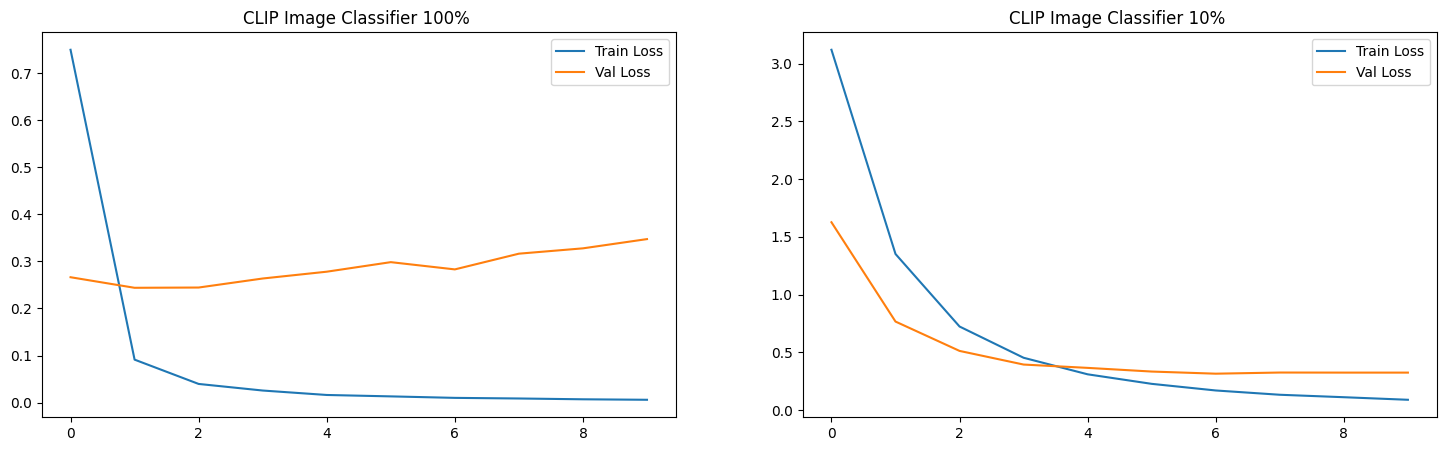

In [ ]:
plt.figure(figsize=(18, 5))
plt.subplot(1, 2, 1)
plt.plot(clip_image_classifiers["100"]["history"]["train_loss"], label="Train Loss")
plt.plot(clip_image_classifiers["100"]["history"]["val_loss"], label="Val Loss")
plt.title("CLIP Image Classifier 100% ")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(clip_image_classifiers["10"]["history"]["train_loss"], label="Train Loss")
plt.plot(clip_image_classifiers["10"]["history"]["val_loss"], label="Val Loss")
plt.title("CLIP Image Classifier 10% ")
plt.legend()
plt.savefig(os.path.join(visual_dir, "clip_image_classifiers.png"))
plt.show()

In [ ]:
df = pd.DataFrame({
    "top": clip_image_classifiers["100"]["accuracy"]['Top'],
    "accuracy(100%)": clip_image_classifiers["100"]["accuracy"]['Accuracy'],
    "accuracy(10%)": clip_image_classifiers["10"]["accuracy"]['Accuracy']
    })
df

,top,accuracy(100%),accuracy(10%)
0,1,0.940488,0.923902
1,5,0.985366,0.975610


In [ ]:
df.to_csv(os.path.join(visual_dir, "clip_image_classifiers_evaluation.csv"))



---



In [ ]:
clip_text_classifiers = {}

In [ ]:
clip_text_classifiers["100"] = {"model":CLIPTextClassifier().to(CFG.device)}
clip_text_classifiers["100"]["history"] = trainer(model = clip_text_classifiers["100"]["model"],
                                                 train_loader = train_loader_100,
                                                 valid_loader = val_loader,
                                                 lr = CFG.text_encoder_lr,
                                                 best_path = os.path.join(models_dir, "clip_text_classifier_100.pt")
                                                 )

clip_text_classifiers["100"]["accuracy"] = accuracy_score(clip_text_classifiers["100"]["model"], val_loader)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Epoch: 1


  0%|          | 0/1890 [00:00<?, ?it/s]

  0%|          | 0/81 [00:00<?, ?it/s]

...

  0%|          | 0/81 [00:00<?, ?it/s]

Epoch: 10


  0%|          | 0/1890 [00:00<?, ?it/s]

  0%|          | 0/81 [00:00<?, ?it/s]

  0%|          | 0/81 [00:00<?, ?it/s]

In [ ]:
clip_text_classifiers["10"] = {"model":CLIPTextClassifier().to(CFG.device)}
clip_text_classifiers["10"]["history"] = trainer(model = clip_text_classifiers["10"]["model"],
                                                 train_loader = train_loader_10,
                                                 valid_loader = val_loader,
                                                 lr = CFG.text_encoder_lr,
                                                 best_path = os.path.join(models_dir, "clip_text_classifier_10.pt")
                                                 )

clip_text_classifiers["10"]["accuracy"] = accuracy_score(clip_text_classifiers["10"]["model"], val_loader)

Epoch: 1


  0%|          | 0/189 [00:00<?, ?it/s]

  0%|          | 0/81 [00:00<?, ?it/s]

Saved Best Model!
Epoch: 2


  0%|          | 0/189 [00:00<?, ?it/s]

...

  0%|          | 0/81 [00:00<?, ?it/s]

Epoch: 10


  0%|          | 0/189 [00:00<?, ?it/s]

  0%|          | 0/81 [00:00<?, ?it/s]

  0%|          | 0/81 [00:00<?, ?it/s]

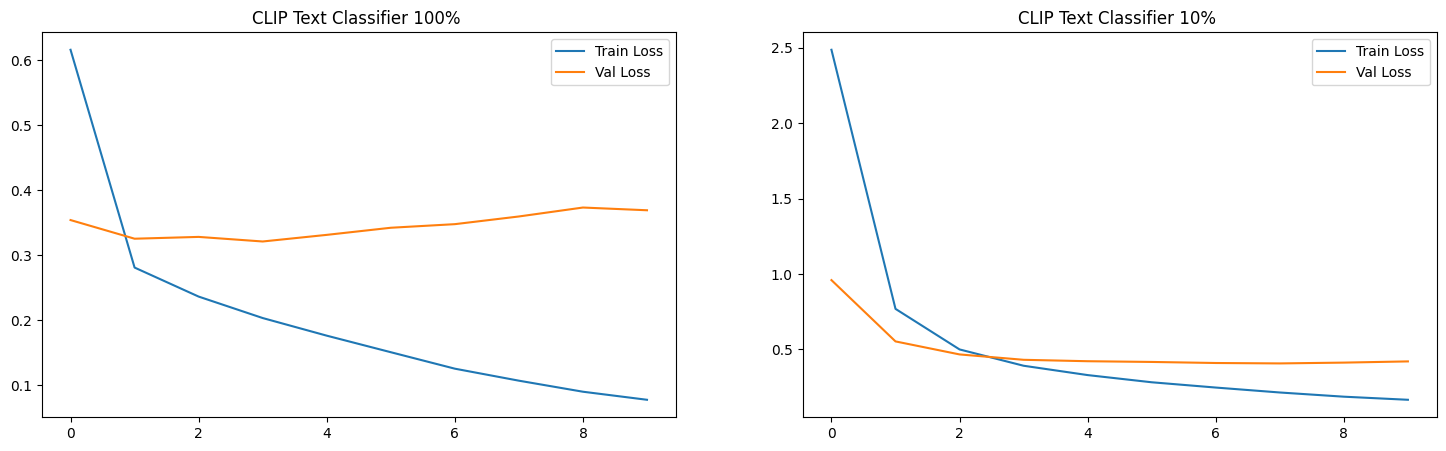

In [ ]:
plt.figure(figsize=(18, 5))
plt.subplot(1, 2, 1)
plt.plot(clip_text_classifiers["100"]["history"]["train_loss"], label="Train Loss")
plt.plot(clip_text_classifiers["100"]["history"]["val_loss"], label="Val Loss")
plt.title("CLIP Text Classifier 100% ")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(clip_text_classifiers["10"]["history"]["train_loss"], label="Train Loss")
plt.plot(clip_text_classifiers["10"]["history"]["val_loss"], label="Val Loss")
plt.title("CLIP Text Classifier 10% ")
plt.legend()
plt.savefig(os.path.join(visual_dir, "clip_text_classifiers.png"))
plt.show()

In [ ]:
df = pd.DataFrame({
    "top": clip_text_classifiers["100"]["accuracy"]['Top'],
    "accuracy(100%)": clip_text_classifiers["100"]["accuracy"]['Accuracy'],
    "accuracy(10%)": clip_text_classifiers["10"]["accuracy"]['Accuracy']
    })
df

,top,accuracy(100%),accuracy(10%)
0,1,0.922927,0.910829
1,5,0.970732,0.961366


In [ ]:
df.to_csv(os.path.join(visual_dir, "clip_text_classifiers_evaluation.csv"))

### Multimodal Classification

In [ ]:
clip_midfusion_classifiers = {}

In [ ]:
clip_midfusion_classifiers["100"] = {"model":CLIPMidFusionClassifier().to(CFG.device)}
clip_midfusion_classifiers["100"]["history"] = trainer(model = clip_midfusion_classifiers["100"]["model"],
                                                       train_loader = train_loader_100,
                                                       valid_loader = val_loader,
                                                       lr = CFG.head_lr,
                                                       best_path = os.path.join(models_dir, "clip_mid_fusion_classifier_100.pt")
                                                       )

clip_midfusion_classifiers["100"]["accuracy"] = accuracy_score(clip_midfusion_classifiers["100"]["model"], val_loader)

Epoch: 1


  0%|          | 0/1890 [00:00<?, ?it/s]

  0%|          | 0/81 [00:00<?, ?it/s]

Saved Best Model!
Epoch: 2


  0%|          | 0/1890 [00:00<?, ?it/s]

...

  0%|          | 0/81 [00:00<?, ?it/s]

Epoch: 10


  0%|          | 0/1890 [00:00<?, ?it/s]

  0%|          | 0/81 [00:00<?, ?it/s]

  0%|          | 0/81 [00:00<?, ?it/s]

In [ ]:
clip_midfusion_classifiers["10"] = {"model":CLIPMidFusionClassifier().to(CFG.device)}
clip_midfusion_classifiers["10"]["history"] = trainer(model = clip_midfusion_classifiers["10"]["model"],
                                                      train_loader = train_loader_10,
                                                      valid_loader = val_loader,
                                                      lr = CFG.head_lr,
                                                      best_path = os.path.join(models_dir, "clip_mid_fusion_classifier_10.pt")
                                                      )

clip_midfusion_classifiers["10"]["accuracy"] = accuracy_score(clip_midfusion_classifiers["10"]["model"], val_loader)

Epoch: 1


  0%|          | 0/189 [00:00<?, ?it/s]

  0%|          | 0/81 [00:00<?, ?it/s]

Saved Best Model!
Epoch: 2


  0%|          | 0/189 [00:00<?, ?it/s]

...

  0%|          | 0/81 [00:00<?, ?it/s]

Saved Best Model!
Epoch: 10


  0%|          | 0/189 [00:00<?, ?it/s]

  0%|          | 0/81 [00:00<?, ?it/s]

  0%|          | 0/81 [00:00<?, ?it/s]

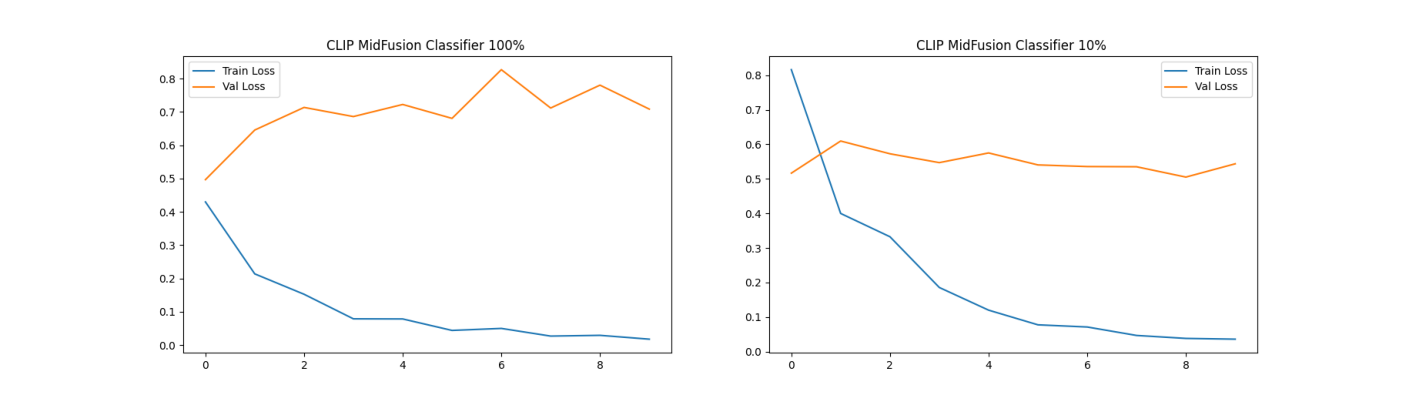

In [ ]:
plt.figure(figsize=(18, 5))
plt.subplot(1, 2, 1)
plt.plot(clip_midfusion_classifiers["100"]["history"]["train_loss"], label="Train Loss")
plt.plot(clip_midfusion_classifiers["100"]["history"]["val_loss"], label="Val Loss")
plt.title("CLIP MidFusion Classifier 100% ")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(clip_midfusion_classifiers["10"]["history"]["train_loss"], label="Train Loss")
plt.plot(clip_midfusion_classifiers["10"]["history"]["val_loss"], label="Val Loss")
plt.title("CLIP MidFusion Classifier 10% ")
plt.legend()
plt.savefig(os.path.join(visual_dir, "clip_midfusion_classifiers.png"))
plt.show()

In [ ]:
df = pd.DataFrame({
    "top": clip_midfusion_classifiers["100"]["accuracy"]['Top'],
    "accuracy(100%)": clip_midfusion_classifiers["100"]["accuracy"]['Accuracy'],
    "accuracy(10%)": clip_midfusion_classifiers["10"]["accuracy"]['Accuracy']
    })
df

,top,accuracy(100%),accuracy(10%)
0,1,0.883902,0.893659
1,5,0.966829,0.967805


In [ ]:
df.to_csv(os.path.join(visual_dir, "clip_midfusion_classifiers_evaluation.csv"))



---



### SimCLR

In [ ]:
class SimCLRDataset(COCOSingleClassDataset):
    def __init__(
            self,
            data_dir: str = CFG.data_path,
            split: str = 'train',
            transforms: Optional[Callable] = None,
            tokenizer: Optional[Callable] = None,
            max_token_length: int = 200,
            max_samples: int = -1,
            max_captions_per_image: int = 5,
            labeled_ratio=0.1,
            labeled=True
            ) -> None:
            super().__init__(data_dir,
                             split,
                             transforms,
                             tokenizer,
                             max_token_length,
                             max_samples,
                             max_captions_per_image
                             )
            self.labeled = labeled
            self.df_labeled, self.df_unlabeled = self.split_labeled_unlabeled(self.df_samples, labeled_ratio)
            self.df_samples = self.df_labeled if self.labeled else self.df_unlabeled



    def __getitem__(self, idx):
        row = self.df_samples.iloc[idx]
        image = Image.open(row["image"]).convert("RGB")
        item = {'image':image,'caption':row['caption']}

        if self.labeled:
            item['label'] = torch.tensor(row['label'],dtype=torch.uint8)
        if self.transforms:
            item['image'] = self.transforms(image)

        return item

    @staticmethod
    def split_labeled_unlabeled(df, labeled_ratio=0.1):
        df_labeled, df_unlabeled = train_test_split(
            df, stratify=df["label"], test_size=1 - labeled_ratio, random_state=CFG.random_seed
        )
        return df_labeled.reset_index(drop=True), df_unlabeled.reset_index(drop=True)


# .......................................................................

def get_dataloaders(labeled_ds, unlabeled_ds, val_ds, cfg=CFG):
    labeled_loader = DataLoader(labeled_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers)
    unlabeled_loader = DataLoader(unlabeled_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
    return labeled_loader, unlabeled_loader, val_loader


In [ ]:
class ContrastiveTransformations(object):
    def __init__(self, base_transforms, n_views=2):
        self.base_transforms = base_transforms
        self.n_views = n_views

    def __call__(self, x):
        return [self.base_transforms(x) for i in range(self.n_views)]




simclr_transform = transforms.Compose([ transforms.Resize(size=(CFG.size, CFG.size), antialias=True),
                                        transforms.RandomHorizontalFlip(),
                                        transforms.RandomResizedCrop(size=96),
                                        transforms.RandomApply([
                                            transforms.ColorJitter(brightness=0.5,
                                                                    contrast=0.5,
                                                                    saturation=0.5,
                                                                    hue=0.1)
                                            ], p=0.8),
                                        transforms.RandomGrayscale(p=0.2),
                                        transforms.GaussianBlur(kernel_size=9),
                                        transforms.ToTensor(),
                                        transforms.Normalize((0.5,), (0.5,))
                                        ])


simclr_transform = ContrastiveTransformations(simclr_transform, n_views=2)

In [ ]:
labeled_dataset = SimCLRDataset(data_dir=CFG.data_path,
                                split="train",
                                transforms=simclr_transform,
                                max_samples=CFG.max_samples,
                                max_captions_per_image=1,
                                labeled=True,
                                labeled_ratio=0.1
                                )

unlabeled_dataset  = SimCLRDataset(data_dir=CFG.data_path,
                                   split="train",
                                   transforms=simclr_transform,
                                   max_samples=CFG.max_samples,
                                   max_captions_per_image=1,
                                   labeled=False,
                                   labeled_ratio=0.1
                                   )

test_dataset = COCOSingleClassDataset(data_dir=CFG.data_path,
                                     split='val',
                                     transforms=get_transforms(mode="val"),
                                     max_samples=CFG.max_samples,
                                     max_captions_per_image=1,
                                     )


labeled_loader, unlabeled_loader, test_loader = get_dataloaders(labeled_dataset,
                                                                unlabeled_dataset,
                                                                test_dataset,
                                                                cfg=CFG
                                                               )

print(f"Labeled dataset size: {len(labeled_dataset)}")
print(f"Unlabeled dataset size: {len(unlabeled_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print("."*50)
print(f"Labeled loader size: {len(labeled_loader)}")
print(f"Unlabeled loader size: {len(unlabeled_loader)}")
print(f"Test loader size: {len(test_loader)}")

Generating train2017 samples...


  0%|          | 0/24186 [00:00<?, ?it/s]

Skipped corrupted image ./coco_single_class/train2017/000000156113.jpg
Generating train2017 samples...


  0%|          | 0/24186 [00:00<?, ?it/s]

Skipped corrupted image ./coco_single_class/train2017/000000156113.jpg
Generating val2017 samples...


  0%|          | 0/1025 [00:00<?, ?it/s]

Labeled dataset size: 2418
Unlabeled dataset size: 21767
Test dataset size: 1025
..................................................
Labeled loader size: 38
Unlabeled loader size: 341
Test loader size: 17


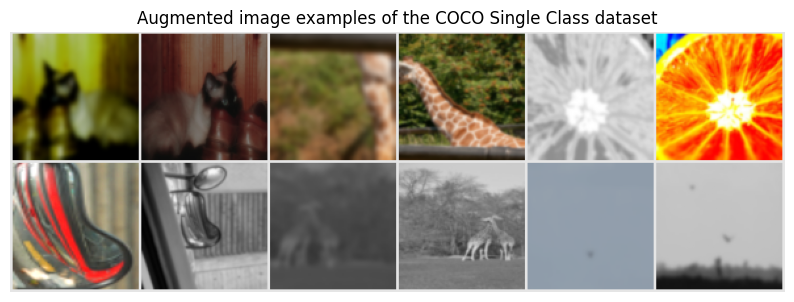

In [ ]:
torch.manual_seed(CFG.random_seed)

imgs = torch.stack([img for idx in range(6) for img in unlabeled_dataset[idx]["image"]], dim=0)
img_grid = torchvision.utils.make_grid(imgs, nrow=6, normalize=True, pad_value=0.9)
img_grid = img_grid.permute(1, 2, 0)

plt.figure(figsize=(10,5))
plt.title('Augmented image examples of the COCO Single Class dataset')
plt.imshow(img_grid)
plt.axis('off')
plt.show()
plt.close()

In [ ]:
class SimCLR(nn.Module):
    def __init__(self, hidden_dim: int = 128, temperature: float = 0.07):
        super().__init__()
        assert temperature > 0.0, "Temperature must be positive!"
        self.temperature = temperature
        self.hidden_dim = hidden_dim
        # Base encoder f(.): ResNet-18 without final fully-connected layer
        base_model = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
        self.encoder = nn.Sequential(*list(base_model.children())[:-1])  # remove fc
        feat_dim = base_model.fc.in_features

        # Projection head g(.): two-layer MLP
        self.projector = nn.Sequential(
            nn.Linear(feat_dim, 4 * hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(4 * hidden_dim, hidden_dim)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass that returns a normalized embedding.
        Input:
            x: Tensor of shape [B, C, H, W]
        Returns:
            z: Tensor of shape [B, hidden_dim], L2-normalized
        """
        h = self.encoder(x)               # [B, feat_dim, 1, 1]
        h = torch.flatten(h, start_dim=1) # [B, feat_dim]
        z = self.projector(h)             # [B, hidden_dim]
        z = F.normalize(z, dim=1)         # L2 normalize
        return z

    def info_nce_loss(self, z: torch.Tensor) -> tuple:
        """
        Compute the NT-Xent (InfoNCE) loss on embeddings z.
        Input:
            z: Tensor of shape [2*B, hidden_dim], containing embeddings
               for two augmented views concatenated along dim=0.
        Returns:
            loss: scalar tensor (mean loss)
            logits: similarity matrix [2B, 2B]
            pos_mask: boolean mask indicating positive pairs
        """
        batch_size = z.size(0) // 2

        # 1) Compute cosine similarity matrix between all pairs
        sim_matrix = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=-1)  # [2B, 2B]

        # 2) Mask self-similarity
        self_mask = torch.eye(sim_matrix.size(0), device=z.device).bool()
        sim_matrix.masked_fill_(self_mask, -9e15)

        # 3) Positive pairs are offset by batch_size along diagonal
        pos_mask = self_mask.roll(shifts=batch_size, dims=0)

        # 4) Compute loss
        logits = sim_matrix / self.temperature
        log_prob = torch.logsumexp(logits, dim=1)           # [2B]
        loss = -logits[pos_mask] + log_prob                  # [2B]
        return loss.mean(), logits, pos_mask

    def compute_metrics(self, logits: torch.Tensor, pos_mask: torch.Tensor) -> tuple:
        """
        Compute evaluation metrics: top1 accuracy, top5 accuracy, and mean positive rank.
        Input:
            logits: Tensor of shape [2B, 2B] (similarity scores / temperature)
            pos_mask: boolean mask of shape [2B, 2B], True where pairs are positives
        Returns:
            acc_top1, acc_top5, mean_pos
        """
        pos_scores = logits[pos_mask].unsqueeze(1)               # [2B, 1]
        neg_scores = logits.masked_fill(pos_mask, -9e15)         # [2B, 2B]
        combined = torch.cat([pos_scores, neg_scores], dim=1)    # [2B, 2B]
        rankings = combined.argsort(dim=1, descending=True).argmin(dim=1)  # [2B]

        acc_top1 = (rankings == 0).float().mean().item()
        acc_top5 = (rankings < 5).float().mean().item()
        mean_pos = (1 + rankings.float().mean()).item()
        return acc_top1, acc_top5, mean_pos

In [ ]:
# Evaluation Function
def evaluate(model: SimCLR, val_loader: DataLoader, device: torch.device) -> dict:
    """
    Run the model on the validation set (no gradient updates) and collect loss and metrics.
    Returns:
        Dictionary with keys: loss, acc_top1, acc_top5, mean_pos
    """
    model.eval()
    total_loss = 0.0
    total_acc1 = 0.0
    total_acc5 = 0.0
    total_meanpos = 0.0
    n_batches = len(val_loader)

    with torch.no_grad():
        for batch in val_loader:
            x1, x2 = batch["image"]
            x1 = x1.to(device)
            x2 = x2.to(device)

            z1 = model(x1)                  # [B, hidden_dim]
            z2 = model(x2)                  # [B, hidden_dim]
            z = torch.cat([z1, z2], dim=0)  # [2B, hidden_dim]

            loss, logits, pos_mask = model.info_nce_loss(z)
            acc1, acc5, mean_pos = model.compute_metrics(logits, pos_mask)

            total_loss += loss.item()
            total_acc1 += acc1
            total_acc5 += acc5
            total_meanpos += mean_pos

    return {
        "loss": total_loss / n_batches,
        "acc_top1": total_acc1 / n_batches,
        "acc_top5": total_acc5 / n_batches,
        "mean_pos": total_meanpos / n_batches
    }


In [ ]:
# Training Function
def train_simclr(model: SimCLR,
                 train_loader: DataLoader,
                 val_loader: DataLoader,
                 cfg: CFG) -> tuple:
    """
    Train SimCLR for cfg.epochs epochs, saving the best checkpoint based on val_top5 accuracy.
    Returns:
        - model with best parameters loaded
        - DataFrame capturing loss and metrics history
    """
    model = model.to(cfg.device)
    optimizer = optim.AdamW(model.parameters(), lr=cfg.head_lr, weight_decay=cfg.weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs, eta_min=cfg.head_lr / 50)

    history = {
        "epoch": [],
        "loss_train": [],
        "loss_val": [],
        "acc_top1": [],
        "acc_top5": [],
        "mean_pos": []
    }
    best_acc_top5 = 0.0
    best_path = os.path.join(cfg.output_dir,"models", "simclr_best.pth")
    os.makedirs(os.path.dirname(best_path), exist_ok=True)

    for epoch in range(cfg.epochs):
        model.train()
        running_loss = 0.0
        n_train_batches = len(train_loader)

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{cfg.epochs}"):
            x1, x2 = batch["image"]
            x1 = x1.to(cfg.device)
            x2 = x2.to(cfg.device)

            # Forward pass and compute loss
            z1 = model(x1)
            z2 = model(x2)
            z = torch.cat([z1, z2], dim=0)
            loss, logits, pos_mask = model.info_nce_loss(z)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        scheduler.step()  # Update learning rate

        # Evaluate on validation set
        val_metrics = evaluate(model, val_loader, cfg.device)

        # Record history
        history["epoch"].append(epoch + 1)
        history["loss_train"].append(running_loss / n_train_batches)
        history["loss_val"].append(val_metrics["loss"])
        history["acc_top1"].append(val_metrics["acc_top1"])
        history["acc_top5"].append(val_metrics["acc_top5"])
        history["mean_pos"].append(val_metrics["mean_pos"])

        # Print summary for this epoch
        print(f"[Epoch {epoch+1}/{cfg.epochs}] "
              f"TrainLoss: {running_loss/n_train_batches:.4f} | "
              f"ValLoss: {val_metrics['loss']:.4f} | "
              f"Top1: {val_metrics['acc_top1']:.3f} | "
              f"Top5: {val_metrics['acc_top5']:.3f} | "
              f"MeanPos: {val_metrics['mean_pos']:.2f}")

        # Save best checkpoint
        if val_metrics["acc_top5"] > best_acc_top5:
            best_acc_top5 = val_metrics["acc_top5"]
            torch.save(model.state_dict(), best_path)
            print(f"Best model saved (Top5: {best_acc_top5:.3f})")

    # Load best parameters
    model.load_state_dict(torch.load(best_path))
    df_history = pd.DataFrame(history)
    return model, df_history

In [ ]:
simclr_model = SimCLR(hidden_dim=128, temperature=CFG.temperature)
simclr_model, df_history = train_simclr(simclr_model,
                                        train_loader=unlabeled_loader,
                                        val_loader=labeled_loader,
                                        cfg=CFG
                                        )

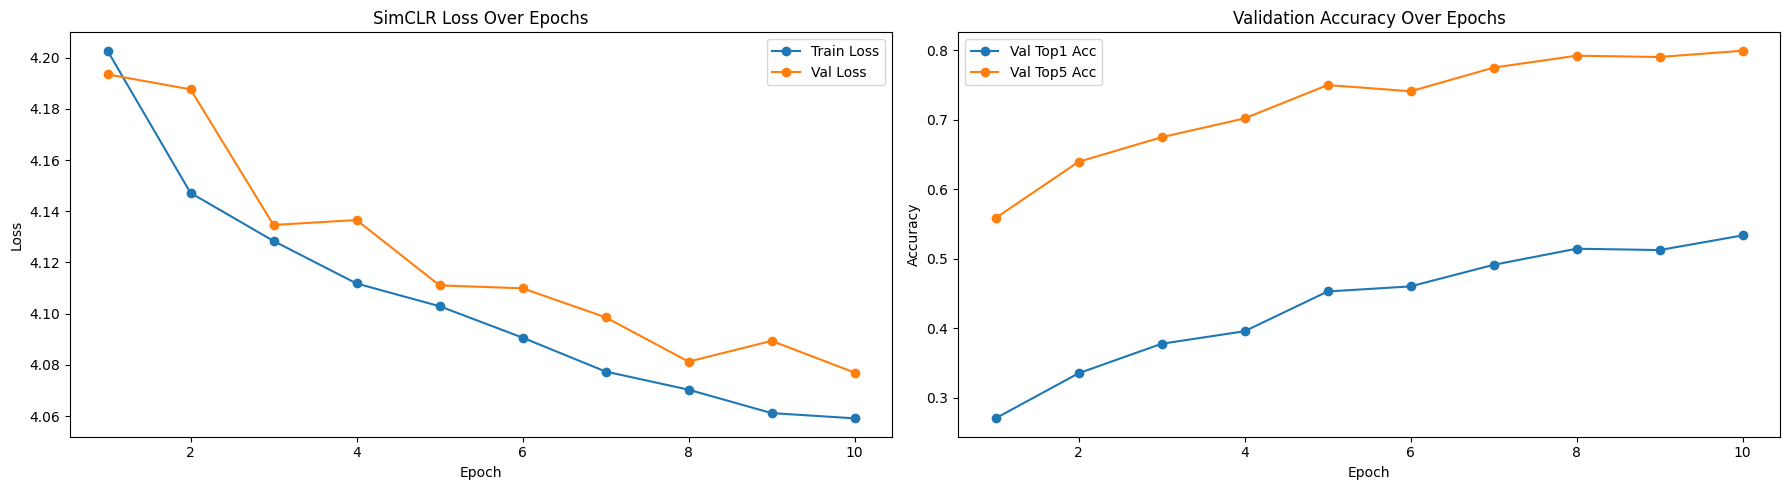

In [ ]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 2, 1)
plt.plot(df_history["epoch"], df_history["loss_train"], label="Train Loss", marker="o")
plt.plot(df_history["epoch"], df_history["loss_val"], label="Val Loss", marker="o")
plt.title("SimCLR Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(df_history["epoch"], df_history["acc_top1"], label="Val Top1 Acc", marker="o")
plt.plot(df_history["epoch"], df_history["acc_top5"], label="Val Top5 Acc", marker="o")
plt.title("Validation Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(visual_dir, "simclr_history.png"))
plt.show()

In [ ]:
df_history

,epoch,loss_train,loss_val,acc_top1,acc_top5,mean_pos
0,1,4.202682,4.193442,0.270469,0.558446,10.535485
1,2,4.147160,4.187596,0.335271,0.639252,9.208947
2,3,4.128373,4.134630,0.377689,0.674646,7.418701
3,4,4.111777,4.136561,0.395715,0.701719,7.273002
4,5,4.102900,4.111032,0.452837,0.749671,5.946472
5,6,4.090628,4.109891,0.460197,0.740683,6.416447
6,7,4.077389,4.098575,0.491201,0.774712,5.501900
7,8,4.070301,4.081255,0.514342,0.791834,5.135559
8,9,4.061157,4.089356,0.512393,0.789975,5.249901
9,10,4.059107,4.076980,0.533495,0.799005,4.684655


In [ ]:
df_history.to_csv(os.path.join(visual_dir, "simclr_evaluaion.csv"), index=False)



---



In [ ]:
# Logistic Regression Model
class LogisticRegression(nn.Module):
    def __init__(self, feature_dim: int, num_classes: int):
        """
        Simple logistic regression (linear) classifier.

        Args:
            feature_dim: Dimensionality of the input features.
            num_classes: Number of classes to predict.
        """
        super().__init__()
        self.linear = nn.Linear(feature_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.

        Args:
            x: Tensor of shape [B, feature_dim]

        Returns:
            logits: Tensor of shape [B, num_classes]
        """
        return self.linear(x)

In [ ]:
#  Evaluation Functions
def evaluate_logreg(model: nn.Module, data_loader: DataLoader, device: torch.device) -> dict:
    """
    Evaluate model on a given DataLoader.

    Args:
        model: Trained logistic regression model.
        data_loader: DataLoader wrapping a TensorDataset of (features, labels).
        device: torch.device ('cuda' or 'cpu').

    Returns:
        Dictionary with keys:
          - loss: average cross-entropy loss
          - accuracy: classification accuracy
    """
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for features, labels in data_loader:
            features = features.to(device)
            labels = labels.to(device)

            logits = model(features)            # [B, num_classes]
            loss = criterion(logits, labels)
            total_loss += loss.item() * labels.size(0)

            preds = logits.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return {"loss": avg_loss, "accuracy": accuracy}

In [ ]:
#  Training Functions
def train_logistic_regression(model: nn.Module,
                              train_dataset: TensorDataset,
                              test_dataset: TensorDataset,
                              cfg: CFG) -> tuple:
    """
    Train logistic regression model and return training history.

    Args:
        model: Instance of LogisticRegression(nn.Module).
        train_dataset: TensorDataset containing (features, labels) for training.
        test_dataset: TensorDataset containing (features, labels) for evaluation.
        cfg: Configuration class containing hyperparameters.

    Returns:
        - trained_model: Logistic regression model with best test accuracy loaded.
        - df_history: pandas DataFrame of training/test metrics over epochs.
    """
    device = cfg.device
    model = model.to(device)

    train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers)
    test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

    optimizer = optim.AdamW(model.parameters(), lr=cfg.head_lr, weight_decay=cfg.weight_decay)
    scheduler = optim.lr_scheduler.MultiStepLR(optimizer,
                                               milestones=[int(cfg.epochs * 0.6), int(cfg.epochs * 0.8)],
                                               gamma=0.1)
    criterion = nn.CrossEntropyLoss()

    history = {
        "epoch": [],
        "loss_train": [],
        "accuracy_train": [],
        "loss_test": [],
        "accuracy_test": []
    }
    best_accuracy = 0.0
    best_path = os.path.join(cfg.output_dir,"models", "logreg_best.pth")
    os.makedirs(os.path.dirname(best_path), exist_ok=True)

    for epoch in range(cfg.epochs):
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_samples = 0

        for features, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{cfg.epochs}"):
            features = features.to(device)
            labels = labels.to(device)

            logits = model(features)                 # [B, num_classes]
            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            preds = logits.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            running_samples += labels.size(0)

        scheduler.step()

        # Compute average training loss and accuracy
        avg_train_loss = running_loss / running_samples
        train_accuracy = running_correct / running_samples

        # Evaluate on test set
        test_metrics = evaluate_logreg(model, test_loader, device)
        test_loss = test_metrics["loss"]
        test_accuracy = test_metrics["accuracy"]

        # Record history
        history["epoch"].append(epoch + 1)
        history["loss_train"].append(avg_train_loss)
        history["accuracy_train"].append(train_accuracy)
        history["loss_test"].append(test_loss)
        history["accuracy_test"].append(test_accuracy)

        # Print summary
        print(f"[Epoch {epoch+1}/{cfg.epochs}] "
              f"TrainLoss: {avg_train_loss:.4f} | TrainAcc: {train_accuracy:.4f} | "
              f"TestLoss: {test_loss:.4f} | TestAcc: {test_accuracy:.4f}")

        # Save checkpoint if best
        if test_accuracy > best_accuracy:
            best_accuracy = test_accuracy
            torch.save(model.state_dict(), best_path)
            print(f"Best logistic model saved (TestAcc: {best_accuracy:.4f})")

    # Load best model weights before returning
    model.load_state_dict(torch.load(best_path))
    df_history = pd.DataFrame(history)
    return model, df_history



In [ ]:
@torch.no_grad()
def extract_features(simclr_model: torch.nn.Module,
                     dataset: Dataset,
                     ) -> TensorDataset:

    simclr_model.eval()
    simclr_model = simclr_model.to(CFG.device)

    # We only need the encoder (ResNet backbone), not the projection head.
    encoder = simclr_model.encoder

    all_features = []
    all_labels = []

    data_loader = DataLoader(dataset,
                             batch_size=CFG.batch_size,
                             shuffle=False,
                             num_workers=CFG.num_workers
                             )

    for batch in tqdm(data_loader, desc="Extracting Features"):
        images = batch["image"]           # Tensor of shape [B, C, H, W]
        labels = batch["label"]           # Tensor of shape [B]

        images = images.to(CFG.device)
        labels = labels.to(CFG.device)

        # Forward pass through encoder only
        feat = encoder(images)            # [B, feat_dim, 1, 1]
        feat = feat.view(feat.size(0), -1)
        all_features.append(feat.cpu())
        all_labels.append(labels.cpu())

    features = torch.cat(all_features, dim=0)  # [N, feat_dim]
    labels = torch.cat(all_labels, dim=0)      # [N]

    # Sort images by labels
    labels, idxs = labels.sort()
    features = features[idxs]

    return TensorDataset(features, labels)

In [ ]:
train_img_data = SimCLRDataset(data_dir=CFG.data_path,
                               split="train",
                               transforms=get_transforms(mode="train"),
                               max_captions_per_image=1,
                               labeled=True,
                               labeled_ratio=0.1
                               )

test_img_data = test_dataset

Generating train2017 samples...


  0%|          | 0/24186 [00:00<?, ?it/s]

Skipped corrupted image ./coco_single_class/train2017/000000156113.jpg


In [ ]:
train_feat_ds = extract_features(simclr_model, train_img_data)
test_feat_ds = extract_features(simclr_model, test_img_data)

In [ ]:
feature_dim = train_feat_ds.tensors[0].shape[1]
logreg_model = LogisticRegression(feature_dim=feature_dim, num_classes=CFG.num_classes)

In [ ]:
trained_model, df_history = train_logistic_regression(
    model=logreg_model,
    train_dataset=train_feat_ds,
    test_dataset=test_feat_ds,
    cfg=CFG
)

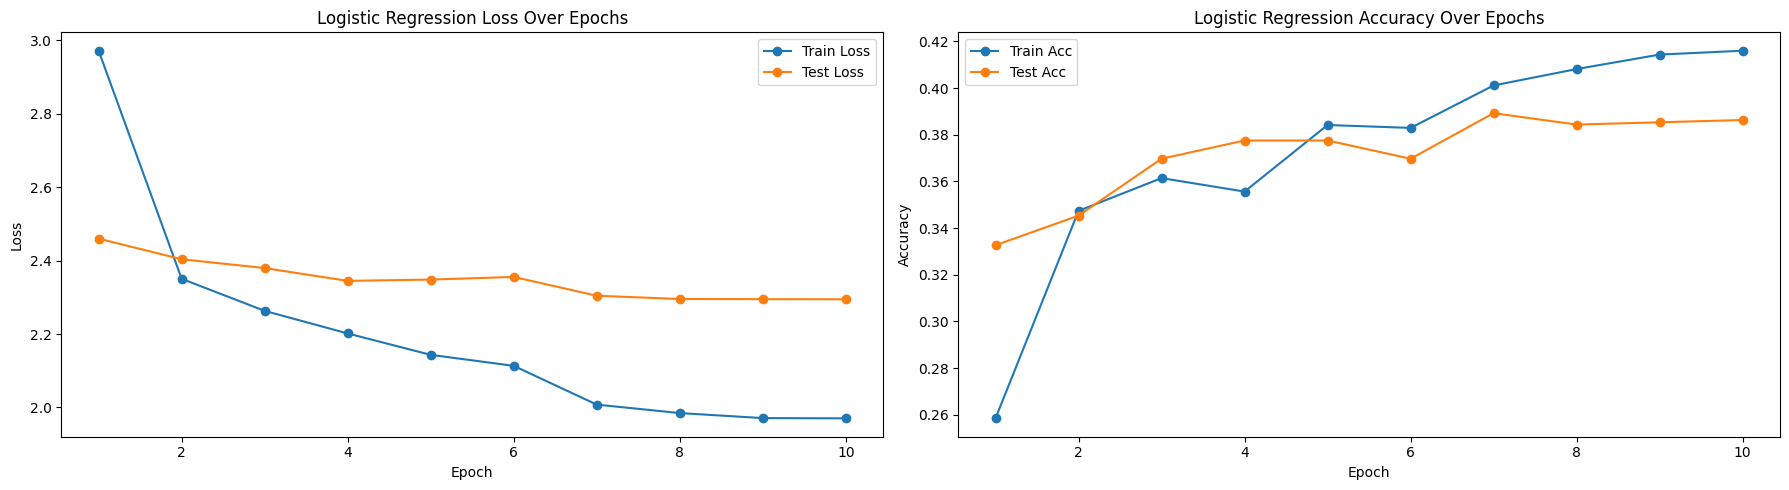

In [ ]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 2, 1)
plt.plot(df_history["epoch"], df_history["loss_train"], label="Train Loss", marker="o")
plt.plot(df_history["epoch"], df_history["loss_test"], label="Test Loss", marker="o")
plt.title("Logistic Regression Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(df_history["epoch"], df_history["accuracy_train"], label="Train Acc", marker="o")
plt.plot(df_history["epoch"], df_history["accuracy_test"], label="Test Acc", marker="o")
plt.title("Logistic Regression Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(visual_dir, "logreg_history.png"))
plt.show()

In [ ]:
df_history

,epoch,loss_train,accuracy_train,loss_test,accuracy_test
0,1,2.971731,0.258478,2.459866,0.332683
1,2,2.350461,0.347395,2.403698,0.345366
2,3,2.263140,0.361456,2.379716,0.369756
3,4,2.201645,0.355666,2.344882,0.377561
4,5,2.143378,0.384202,2.348359,0.377561
5,6,2.113425,0.382961,2.355564,0.369756
6,7,2.007835,0.401158,2.304380,0.389268
7,8,1.984783,0.408189,2.295447,0.384390
8,9,1.971100,0.414392,2.295065,0.385366
9,10,1.970425,0.416046,2.294686,0.386341


In [ ]:
df_history.to_csv(os.path.join(visual_dir, "logreg_evaluaion.csv"), index=False)



---



### Modality Ablation

In [ ]:
class CLIPImageZeroShotModel(CLIPMidFusionClassifier):
    def __init__(self,temperature=CFG.temperature):
        super().__init__()
        self.temperature = temperature
        self.classifier = nn.Identity()


    def forward(self, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
        # Just getting Image Features, as Text Embeddings are pre-computed
        image_features = self.image_encoder(batch["image"])
        # Getting Image and Text Embeddings (with same dimension)
        image_embeddings = self.image_projection(image_features)
        # L2 normalise
        image_embeddings_n = F.normalize(image_embeddings, p=2, dim=-1)
        # Compute logits
        logits = image_embeddings_n @ batch["label_embeddings_n"].T * self.temperature
        return logits


class CLIPTextZeroShotModel(CLIPMidFusionClassifier):
    def __init__(self,temperature=CFG.temperature):
        super().__init__()
        self.temperature = temperature
        self.classifier = nn.Identity()

    def forward(self, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
        # Just getting Text Features, as Image Embeddings are pre-computed
        text_features = self.text_encoder(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        ).last_hidden_state[:, self.target_token_idx, :]
        # Getting Image and Text Embeddings (with same dimension)
        text_embeddings = self.text_projection(text_features)
        # L2 normalise
        text_embeddings_n = F.normalize(text_embeddings, p=2, dim=-1)
        # Compute logits
        logits = text_embeddings_n @ batch["label_embeddings_n"].T * self.temperature
        return logits



def get_label_embeddings(model, valid_loader, tokenizer, query_template="A photo of a "):
    model.eval()
    print("Getting label embeddings...")
    label_list = list(range(CFG.num_classes))
    label_queries = []
    # Generate query sentences, and tokenize them
    for label_id in label_list:
        label_str = valid_loader.dataset.get_class_name(label_id)  # get class name associated with label id
        label_queries.append(f"{query_template}{label_str}.")  # e.g. "A photo of a zebra."
    encoded_queries = tokenizer(
        label_queries, padding=True, truncation=True, max_length=CFG.max_token_length
    )


    # Create batch for queries
    batch = {}
    for key, values in encoded_queries.items():
        batch[key] = torch.tensor(values).to(CFG.device)

    # Get embeddings from model
    with torch.no_grad():
        text_features = model.text_encoder(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
            ).last_hidden_state[:, 0, :]

        label_embeddings = model.text_projection(text_features)

        label_embeddings_n = F.normalize(label_embeddings, p=2, dim=-1)


    return label_embeddings_n, label_list

def zero_shot_eval(model, valid_loader, tokenizer):
    model = model.to(CFG.device)
    model.eval()
    # Pre-compute text embeddings for all classes
    label_embeddings_n, label_list = get_label_embeddings(model, valid_loader, tokenizer, query_template="A photo of a ")
    label_list = np.array(label_list)

    print(f"Evaluating...")

    df_accuracy = accuracy_score(model,
                                 valid_loader,
                                 update_batch={"label_embeddings_n":label_embeddings_n}
                                 )
    return df_accuracy




---



In [ ]:
model_path = os.path.join(models_dir, "clip_mid_fusion_classifier_100.pt")

In [ ]:
clip_text_zero_shot_model = CLIPTextZeroShotModel().to(CFG.device)
clip_text_zero_shot_model.load_state_dict(torch.load(model_path),strict=False)
df_clip_text_zeroshot_accuracy = zero_shot_eval(clip_text_zero_shot_model, val_loader, tokenizer)

Getting label embeddings...
Evaluating...


  0%|          | 0/81 [00:00<?, ?it/s]

In [ ]:
df_clip_text_zeroshot_accuracy.to_csv(os.path.join(visual_dir, "clip_text_zeroshot_evaluation.csv"), index=False)
print("Clip Text Zero Shot Accuracy:")
df_clip_text_zeroshot_accuracy

Clip Text Zero Shot Accuracy:


,Top,Accuracy
0,1,0.010146
1,5,0.084098




---



In [ ]:
clip_image_zero_shot_model = CLIPImageZeroShotModel().to(CFG.device)
clip_image_zero_shot_model.load_state_dict(torch.load(model_path),strict=False)
df_clip_image_zeroshot_accuracy = zero_shot_eval(clip_image_zero_shot_model, val_loader, tokenizer)

In [ ]:
df_clip_image_zeroshot_accuracy.to_csv(os.path.join(visual_dir, "clip_image_zeroshot_evaluation.csv"), index=False)
print("Clip Image Zero Shot Accuracy:")
df_clip_image_zeroshot_accuracy

Clip Image Zero Shot Accuracy:


,Top,Accuracy
0,1,0.011707
1,5,0.093659




---



### Robust

In [ ]:
class RobustCLIPMidFusionClassifier(CLIPMidFusionClassifier):
    """
    Extends CLIPMidFusionClassifier to handle missing modalities during both
    training (random dropout) and inference (explicit drop flags).

    Training-time (self.training == True):
      - Randomly drop image embedding per sample with probability CFG.p_drop_image.
      - Randomly drop text embedding per sample with probability CFG.p_drop_text.
      - If both drops occur for the same sample, keep at least one modality.

    Inference-time (self.training == False):
      - If "drop_image" or "drop_text" in batch_input, use those flags:
          * A single bool → drop that modality for all samples.
          * A Tensor[B] of bool → drop per-sample.
      - If neither flag is provided, no dropout (both modalities used).
    """
    def __init__(self,
                 image_model_name: str = CFG.model_name,
                 text_model_name:  str = CFG.text_encoder_model,
                 pretrained:       bool = CFG.pretrained,
                 trainable:       bool = CFG.trainable,
                 num_classes:      int  = CFG.num_classes):
        super().__init__(image_model_name=image_model_name,
                         text_model_name=text_model_name,
                         pretrained=pretrained,
                         trainable=trainable,
                         num_classes=num_classes)

    def forward(self, batch_input: dict) -> torch.Tensor:
        """
        Args:
            batch_input:
              "image":         Tensor[B, 3, H, W] OR omitted
              "input_ids":     Tensor[B, L]          OR omitted
              "attention_mask":Tensor[B, L]          OR omitted
            Optionally:
              "drop_image": bool or Tensor[B] of bool
              "drop_text":  bool or Tensor[B] of bool

        Returns:
            logits: Tensor[B, num_classes]
        """
        device = CFG.device

        # Determine batch size B from whichever modality is present
        if "image" in batch_input:
            B = batch_input["image"].size(0)
        elif "input_ids" in batch_input:
            B = batch_input["input_ids"].size(0)
        else:
            raise ValueError("batch_input must contain 'image' or both 'input_ids' and 'attention_mask'.")

        # --- Image branch ---
        if "image" in batch_input:
            images = batch_input["image"].to(device)
            img_feats = self.image_encoder(images)            # [B, image_embedding]
            img_proj  = self.image_projection(img_feats)      # [B, projection_dim]
        else:
            # No image → zero projection of matching shape
            img_proj = torch.zeros((B,self.image_projection.embedding_dim))
            img_proj[:] = 0

        # --- Text branch ---
        if ("input_ids" in batch_input) and ("attention_mask" in batch_input):
            input_ids = batch_input["input_ids"].to(device)
            attention_mask = batch_input["attention_mask"].to(device)
            txt_out   = self.text_encoder(input_ids=input_ids,
                                          attention_mask=attention_mask)
            txt_feats = txt_out.last_hidden_state[:, self.target_token_idx, :]  # [B, text_embedding]
            txt_proj  = self.text_projection(txt_feats)         # [B, projection_dim]
        else:
            # No text → zero projection of matching shape
            txt_proj = torch.zeros((B,self.text_projection.embedding_dim))        # [B, projection_dim]
            txt_proj[:] = 0

        # --- Dropout / modality removal ---
        if ("drop_image" in batch_input) or ("drop_text" in batch_input):
            # Inference mode: explicit flags
            # Handle drop_image
            drop_img_flag = batch_input.get("drop_image", False)
            if isinstance(drop_img_flag, bool):
                if drop_img_flag:
                    img_proj.zero_()
            else:
                mask_img = drop_img_flag.to(device)
                if mask_img.any():
                    img_proj[mask_img] = 0

            # Handle drop_text
            drop_txt_flag = batch_input.get("drop_text", False)
            if isinstance(drop_txt_flag, bool):
                if drop_txt_flag:
                    txt_proj.zero_()
            else:
                mask_txt = drop_txt_flag.to(device)
                if mask_txt.any():
                    txt_proj[mask_txt] = 0

        else:
            # Training mode: random per-sample dropout
            if self.training:
                rand_img = torch.rand(B, device=device)
                rand_txt = torch.rand(B, device=device)
                drop_image_mask = rand_img < CFG.p_drop_image
                drop_text_mask  = rand_txt < CFG.p_drop_text

                # Ensure at least one modality remains
                both_mask = drop_image_mask & drop_text_mask
                drop_image_mask[both_mask] = False
                drop_text_mask[both_mask]  = False

                if drop_image_mask.any():
                    img_proj[drop_image_mask] = 0
                if drop_text_mask.any():
                    txt_proj[drop_text_mask] = 0
            # Validation / default inference: no dropout

        # Fuse and classify ---
        fused = torch.cat([img_proj, txt_proj], dim=1)    # [B, 2 * projection_dim]
        logits = self.classifier(fused)                   # [B, num_classes]
        return logits

In [ ]:
robust_model = RobustCLIPMidFusionClassifier(
        image_model_name=CFG.model_name,
        text_model_name=CFG.text_encoder_model,
        pretrained=CFG.pretrained,
        trainable=CFG.trainable,
        num_classes=CFG.num_classes
    ).to(CFG.device)

model.safetensors:   0%|          | 0.00/84.9M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

In [ ]:
CFG.p_drop_image = 0.25
CFG.p_drop_text = 0.25

df_history = trainer(
    model=robust_model,
    train_loader=train_loader_100,
    valid_loader=val_loader,
    lr=CFG.head_lr,
    best_path=os.path.join(models_dir, "robust_fusion_best.pth")
)

Epoch: 1


  0%|          | 0/1890 [00:00<?, ?it/s]

  0%|          | 0/81 [00:00<?, ?it/s]

Saved Best Model!
Epoch: 2


  0%|          | 0/1890 [00:00<?, ?it/s]

...

  0%|          | 0/1890 [00:00<?, ?it/s]

  0%|          | 0/81 [00:00<?, ?it/s]

Epoch: 10


  0%|          | 0/1890 [00:00<?, ?it/s]

  0%|          | 0/81 [00:00<?, ?it/s]

In [ ]:
df_history

,train_loss,val_loss
0,1.100440,0.519379
1,0.905359,0.636804
2,0.846909,0.676380
3,0.763323,0.664252
4,0.760724,0.690932
5,0.728047,0.755691
6,0.729513,0.809203
7,0.705020,0.759911
8,0.712210,0.823580
9,0.695584,0.762507


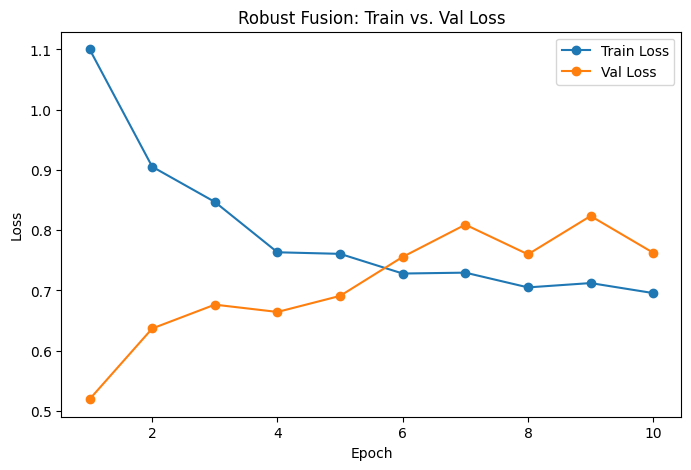

In [ ]:
plt.figure(figsize=(8, 5))
epochs = range(1, len(df_history) + 1)
plt.plot(epochs, df_history["train_loss"], label="Train Loss", marker="o")
plt.plot(epochs, df_history["val_loss"], label="Val Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Robust Fusion: Train vs. Val Loss")
plt.legend()
plt.savefig(os.path.join(visual_dir, "robust_fusion_loss.png"))
plt.show()

In [ ]:
df_both     = accuracy_score(robust_model, val_loader, update_batch={"drop_image": False, "drop_text": False})
df_img_only = accuracy_score(robust_model, val_loader, update_batch={"drop_image": False, "drop_text": True})
df_txt_only = accuracy_score(robust_model, val_loader, update_batch={"drop_image": True,  "drop_text": False})

  0%|          | 0/81 [00:00<?, ?it/s]

  0%|          | 0/81 [00:00<?, ?it/s]

  0%|          | 0/81 [00:00<?, ?it/s]

In [ ]:
display("Both Modalities:", df_both)
display("Image Only:", df_img_only)
display("Text Only:", df_txt_only)

'Both Modalities:'

,Top,Accuracy
0,1,0.884878
1,5,0.960000


'Image Only:'

,Top,Accuracy
0,1,0.881951
1,5,0.960000


'Text Only:'

,Top,Accuracy
0,1,0.070244
1,5,0.300488


In [ ]:
df_both.to_csv(os.path.join(visual_dir, "robust_fusion_acc_both.csv"), index=False)
df_img_only.to_csv(os.path.join(visual_dir, "robust_fusion_acc_image_only.csv"), index=False)
df_txt_only.to_csv(os.path.join(visual_dir, "robust_fusion_acc_text_only.csv"), index=False)

## Delete Runtime

In [ ]:
from google.colab import runtime
runtime.unassign()